# Term Paper 1
## Group: [Your Candidate Numbers]


In [1]:
import numpy as np
from scipy.optimize import root_scalar, minimize_scalar
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Set visual preferences for matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.style.use('default')


## Part 1 — Euler equation errors


In [2]:
@dataclass
class Parameters:
    beta: float = 0.99**30
    gamma: float = 2.1
    tau: float = 0.3
    phi: float = 0.5
    alpha: float = 0.36
    delta: float = 1.0 - 0.94**30
    z: float = 1.0
    Nw: float = 0.8
    Nk: float = 0.2
    # Wealth tax parameter (Part 4)
    tau_a: float = 0.0
    # Uncertainty parameters (Part 6)
    pi_a: float = 0.5
    tau_a_iid: float = 0.05

def u_prime(c, gamma):
    """Marginal utility of consumption for CRRA."""
    return c**(-gamma)

def euler_err(K_next, K, par: Parameters):
    """
    Compute the capitalists' Euler equation error for a given capital 
    stock today (K) and tomorrow (K_next).
    """
    L_t = par.Nw / 2
    k_t = K / L_t
    r_t = par.z * par.alpha * k_t**(par.alpha - 1) - par.delta
    
    k_next = K_next / L_t
    r_next = par.z * par.alpha * k_next**(par.alpha - 1) - par.delta
    
    a_prev = 2 * K / par.Nk
    a_t = 2 * K_next / par.Nk
    
    Ta_t = par.tau_a * (1 + r_t) * K
    Ta_next = par.tau_a * (1 + r_next) * K_next
    
    b_t = par.phi * (1 - par.tau_a) * (1 + r_t) * a_prev
    ck_y_t = b_t + Ta_t - a_t
    
    if ck_y_t <= 0:
        return 1e10  # Penalize negative consumption
        
    ck_o_next = (1 - par.phi) * (1 - par.tau_a) * (1 + r_next) * a_t + Ta_next
    
    if ck_o_next <= 0:
        return -1e10  # Penalize negative consumption
        
    LHS = u_prime(ck_y_t, par.gamma)
    RHS = par.beta * (1 + r_next) * (1 - par.tau_a) * (1 - par.phi) * u_prime(ck_o_next, par.gamma)
    
    return LHS - RHS


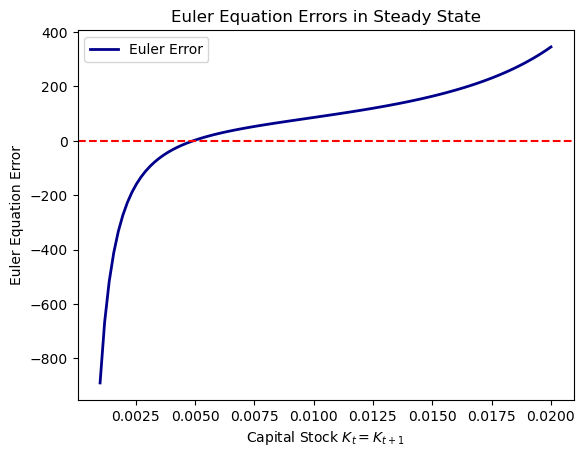

In [3]:
par = Parameters()
K_grid = np.linspace(0.001, 0.02, 100)
errors = [euler_err(K, K, par) for K in K_grid]

# Plotting Euler equation errors
plt.figure()
plt.plot(K_grid, errors, label='Euler Error', color='darkblue', linewidth=2)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Capital Stock $K_t = K_{t+1}$')
plt.ylabel('Euler Equation Error')
plt.title('Euler Equation Errors in Steady State')
plt.legend()
plt.show()


## Part 2 — Steady state


In [4]:
@dataclass
class SteadyState:
    K: float
    Y: float
    w: float
    r: float
    cw_y: float
    cw_o: float
    ck_y: float
    ck_o: float
    a: float
    b: float
    p: float
    L: float
    Ta: float
    st: float

def compute_steady_state(par: Parameters, K_guess=0.01, uncertain=False):
    """
    Computes steady state values using a root-finder to locate the steady-state capital K*.
    """
    if uncertain:
        res = root_scalar(lambda K: euler_err_uncertain(K, K, par), bracket=[1e-5, 1.0])
    else:
        res = root_scalar(lambda K: euler_err(K, K, par), bracket=[1e-5, 1.0])
        
    if not res.converged:
        raise ValueError("Steady state root-finder not converged")
    
    K = res.root
    L = par.Nw / 2
    k = K / L
    Y = par.z * K**par.alpha * L**(1 - par.alpha)
    r = par.z * par.alpha * k**(par.alpha - 1) - par.delta
    w = par.z * (1 - par.alpha) * k**par.alpha
    
    a = 2 * K / par.Nk
    Ta = par.tau_a * (1 + r) * K
    b = par.phi * (1 - par.tau_a) * (1 + r) * a
    
    p = par.tau * w
    
    cw_y = (1 - par.tau) * w + Ta
    cw_o = p + Ta
    
    ck_y = b + Ta - a
    ck_o = (1 - par.phi) * (1 - par.tau_a) * (1 + r) * a + Ta
    
    st = a / (b + Ta)
    
    # Validation: goods market clearing check
    C = (par.Nw / 2) * (cw_y + cw_o) + (par.Nk / 2) * (ck_y + ck_o)
    I = par.delta * K
    assert abs(Y - C - I) < 1e-4, "Goods market clearing violated."
    
    return SteadyState(K=K, Y=Y, w=w, r=r, cw_y=cw_y, cw_o=cw_o, 
                       ck_y=ck_y, ck_o=ck_o, a=a, b=b, p=p, L=L, Ta=Ta, st=st)
                       
ss_base = compute_steady_state(par)
print("--- Steady State ---")
print(f"Output (Y): {ss_base.Y:.5f}")
print(f"Capital (K): {ss_base.K:.5f}")
print(f"Wage (w): {ss_base.w:.5f}")
print(f"Net Return on Capital (r): {ss_base.r:.5f}")
print(f"Young Worker Consumption (cw_y): {ss_base.cw_y:.5f}")
print(f"Old Worker Consumption (cw_o): {ss_base.cw_o:.5f}")
print(f"Young Capitalist Consumption (ck_y): {ss_base.ck_y:.5f}")
print(f"Old Capitalist Consumption (ck_o): {ss_base.ck_o:.5f}")

annualized_r = (1 + ss_base.r)**(1/30) - 1
print(f"\nImplied Annualized Net Interest Rate: {annualized_r:.4%}")


--- Steady State ---
Output (Y): 0.08213
Capital (K): 0.00492
Wage (w): 0.13141
Net Return on Capital (r): 5.16294
Young Worker Consumption (cw_y): 0.09198
Old Worker Consumption (cw_o): 0.03942
Young Capitalist Consumption (ck_y): 0.10246
Old Capitalist Consumption (ck_o): 0.15168

Implied Annualized Net Interest Rate: 6.2493%


## Part 3 — Transition dynamics


In [5]:
@dataclass
class Simulation:
    K: np.ndarray
    Y: np.ndarray
    w: np.ndarray
    r: np.ndarray
    cw_y: np.ndarray
    cw_o: np.ndarray
    ck_y: np.ndarray
    ck_o: np.ndarray
    a: np.ndarray
    b: np.ndarray
    st: np.ndarray

def simulate_olg(K0, T, par: Parameters, uncertain=False):
    """
    Computes transition path from initial capital stock K0 for T periods.
    """
    K = np.zeros(T + 1)
    K[0] = K0
    
    for t in range(T):
        if uncertain:
            res = root_scalar(lambda K_next: euler_err_uncertain(K_next, K[t], par), bracket=[1e-5, 1.0])
        else:
            res = root_scalar(lambda K_next: euler_err(K_next, K[t], par), bracket=[1e-5, 1.0])
        K[t+1] = res.root
        
    K_t = K[:-1]
    K_next = K[1:]
    
    L = par.Nw / 2
    Y = par.z * K_t**par.alpha * L**(1 - par.alpha)
    r = par.z * par.alpha * (K_t / L)**(par.alpha - 1) - par.delta
    w = par.z * (1 - par.alpha) * (K_t / L)**par.alpha
    
    a = 2 * K_next / par.Nk
    a_prev = 2 * K_t / par.Nk
    
    Ta = par.tau_a * (1 + r) * K_t
    b = par.phi * (1 - par.tau_a) * (1 + r) * a_prev
    
    st = a / (b + Ta)
    
    p = par.tau * w
    cw_y = (1 - par.tau) * w + Ta
    cw_o = p + Ta
    ck_y = b + Ta - a
    ck_o = (1 - par.phi) * (1 - par.tau_a) * (1 + r) * a_prev + Ta
    
    # Validation: goods market clearing check in each period
    C = (par.Nw / 2) * (cw_y + cw_o) + (par.Nk / 2) * (ck_y + ck_o)
    I = K_next - (1 - par.delta) * K_t
    assert np.all(np.abs(Y - C - I) < 1e-4), "Goods market clearing violated during transition."
    
    return Simulation(K=K_t, Y=Y, w=w, r=r, cw_y=cw_y, cw_o=cw_o, 
                      ck_y=ck_y, ck_o=ck_o, a=a, b=b, st=st)

# Simulate from K0 = K*/2 for 20 periods
sim_base = simulate_olg(ss_base.K / 2, T=20, par=par)


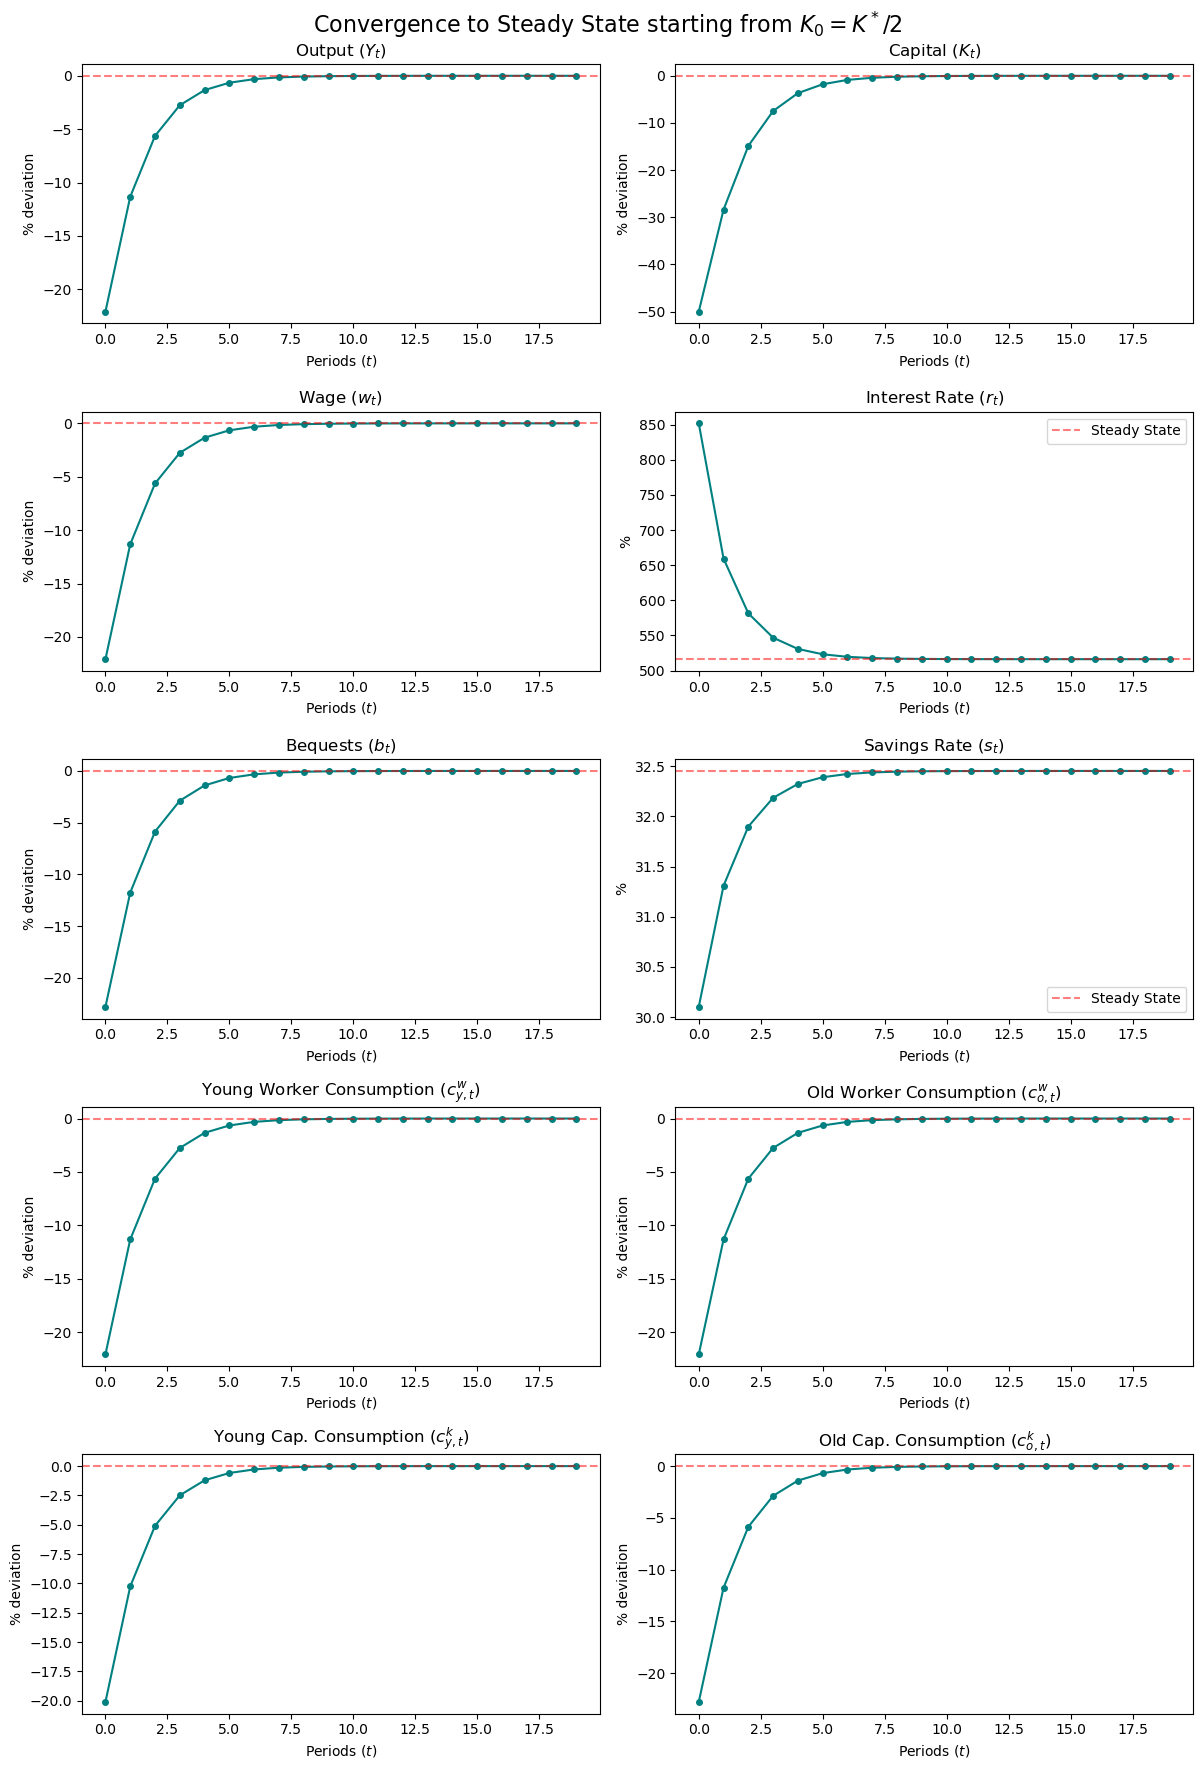

In [6]:
def plot_simulation(sim: Simulation, title="Transition Dynamics"):
    """Creates a 5-by-2 subplot showing the simulated series."""
    ss_vals = {
        'Y': sim.Y[-1], 'K': sim.K[-1], 'w': sim.w[-1],
        'b': sim.b[-1], 'cw_y': sim.cw_y[-1], 'cw_o': sim.cw_o[-1],
        'ck_y': sim.ck_y[-1], 'ck_o': sim.ck_o[-1]
    }
    
    fig, axes = plt.subplots(5, 2, figsize=(12, 18))
    fig.suptitle(title, fontsize=16)
    
    def pct_dev(series, stat):
        return (series - stat) / stat * 100
        
    metrics = [
        ('Output ($Y_t$)', pct_dev(sim.Y, ss_vals['Y']), "% deviation"),
        ('Capital ($K_t$)', pct_dev(sim.K, ss_vals['K']), "% deviation"),
        ('Wage ($w_t$)', pct_dev(sim.w, ss_vals['w']), "% deviation"),
        ('Interest Rate ($r_t$)', sim.r * 100, "%"),
        ('Bequests ($b_t$)', pct_dev(sim.b, ss_vals['b']), "% deviation"),
        ('Savings Rate ($s_t$)', sim.st * 100, "%"),
        ('Young Worker Consumption ($c^w_{y,t}$)', pct_dev(sim.cw_y, ss_vals['cw_y']), "% deviation"),
        ('Old Worker Consumption ($c^w_{o,t}$)', pct_dev(sim.cw_o, ss_vals['cw_o']), "% deviation"),
        ('Young Cap. Consumption ($c^k_{y,t}$)', pct_dev(sim.ck_y, ss_vals['ck_y']), "% deviation"),
        ('Old Cap. Consumption ($c^k_{o,t}$)', pct_dev(sim.ck_o, ss_vals['ck_o']), "% deviation")
    ]
    
    t = np.arange(len(sim.K))
    for ax, (name, data, unit) in zip(axes.flatten(), metrics):
        ax.plot(t, data, marker='o', markersize=4, linestyle='-', color='teal')
        ax.set_title(name)
        ax.set_xlabel('Periods ($t$)')
        ax.set_ylabel(unit)
        ax.axhline(data[-1], color='red', linestyle='--', alpha=0.5, label='Steady State')
        if name in [ 'Interest Rate ($r_t$)', 'Savings Rate ($s_t$)' ]:
            ax.legend()
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

plot_simulation(sim_base, "Convergence to Steady State starting from $K_0 = K^*/2$")


## Part 4 — Introduction of a wealth tax


In [ ]:
# Introduce a wealth tax
par_tax = Parameters(tau_a=0.05)
ss_tax = compute_steady_state(par_tax)


print("--- Steady State Comparison ---")
print(f"Initial SS Savings Rate: {ss_base.st:.4%}")
print(f"Tax SS Savings Rate:     {ss_tax.st:.4%}")
print(f"Initial SS Capital (K):  {ss_base.K:.5f}")
print(f"Tax SS Capital (K):      {ss_tax.K:.5f}")


--- Steady State Comparison ---
Initial SS Savings Rate: 32.4520%
Tax SS Savings Rate:     32.2830%
Initial SS Capital (K):  0.00492
Tax SS Capital (K):      0.00457


Because the wealth tax expropriates part of capitalists' inherited wealth and cuts their net return on savings, the incentive to accumulate assets diminishes heavily. This directly lowers the savings rate $s_t$, which shrinks total investment and reduces the aggregate capital stock $K$ in the new steady state.


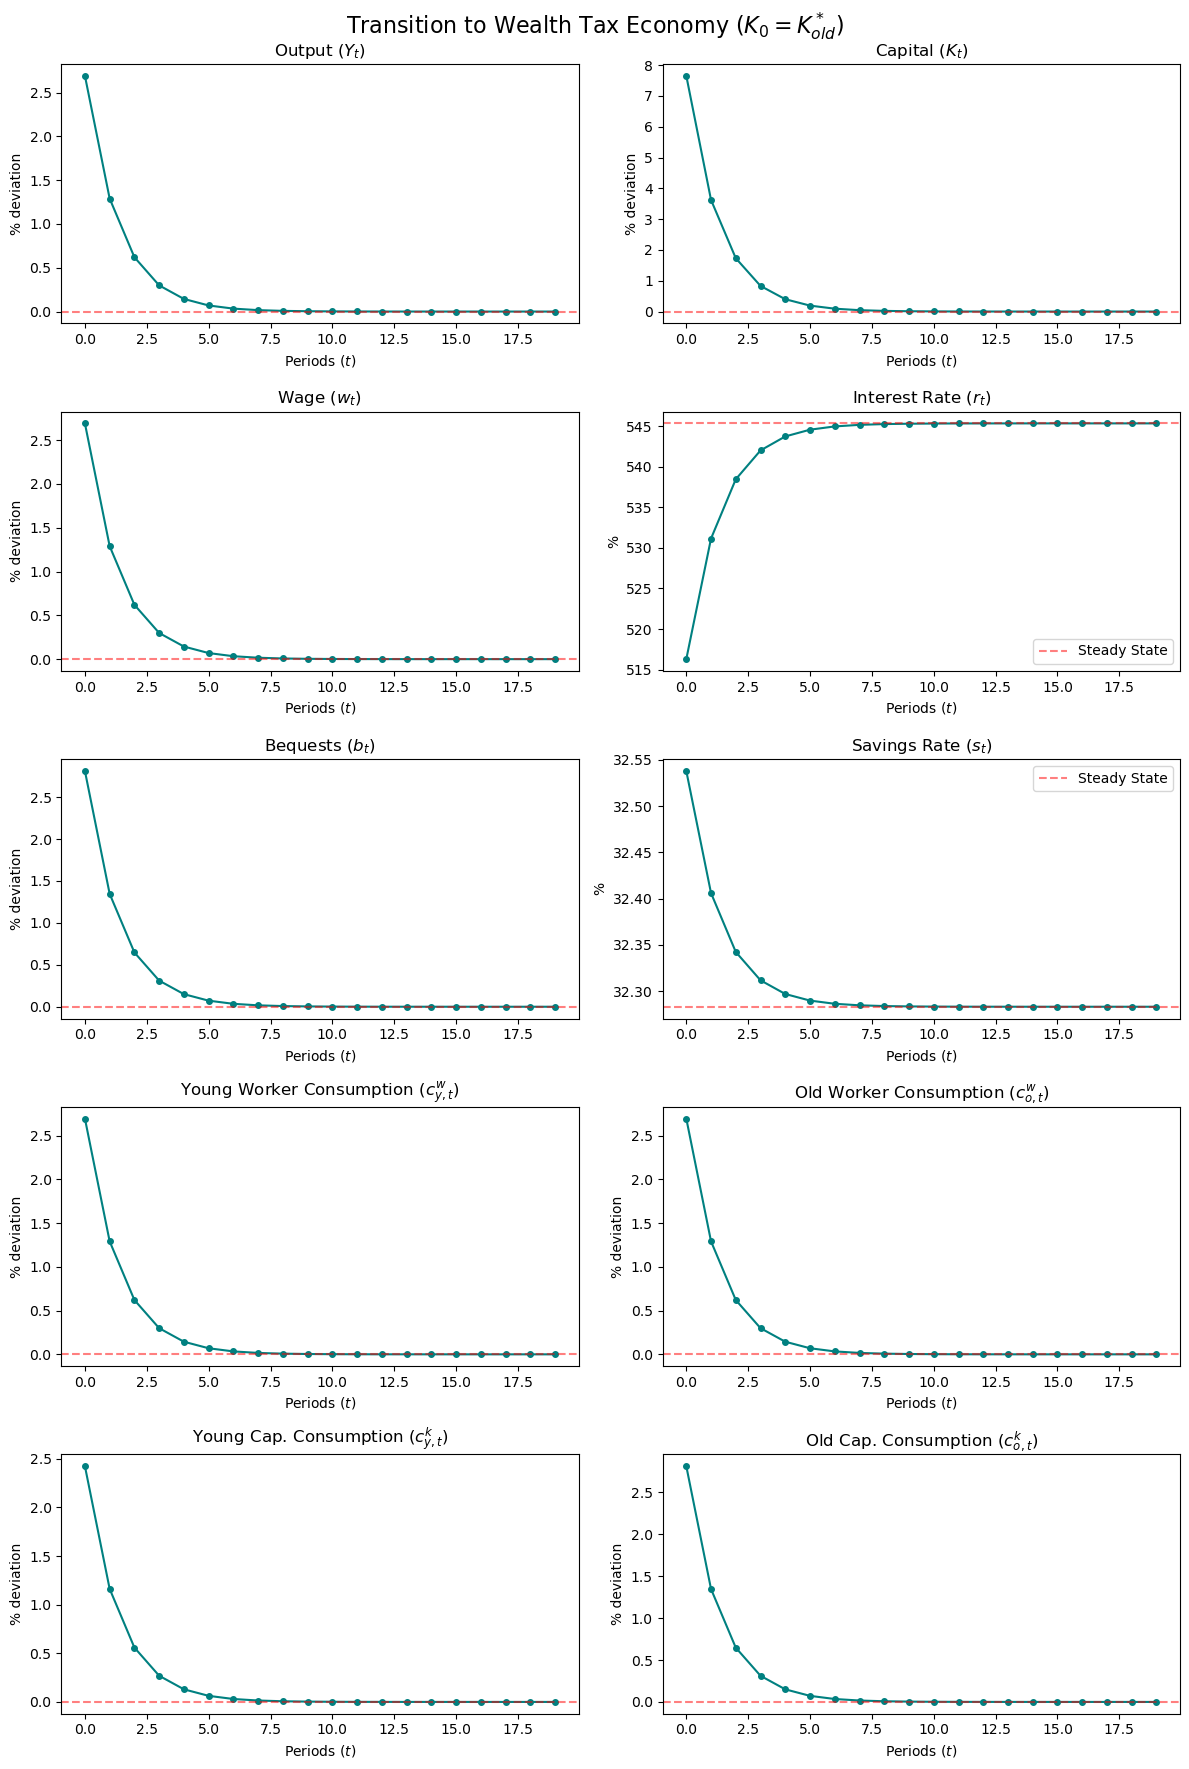

In [8]:
# The economy runs with `par` (no tax) and starts in `ss_base`.
# In t=0, the tax `par_tax` is enacted.
sim_tax = simulate_olg(ss_base.K, T=20, par=par_tax)
plot_simulation(sim_tax, "Transition to Wealth Tax Economy ($K_0 = K^*_{old}$)")


Initially, workers receive a massive benefit from the unexpected lump-sum wealth transfers, boosting their immediate consumption while real wages haven't dropped significantly yet. However, as capital structurally declines towards the lower steady state, diminished investment severely drags down aggregate labor productivity, depressing real wages. Eventually, the long-run reduction in output outweighs the transfer benefits, leaving all cohorts—workers and capitalists—worse off in the new steady state than they were before.


## Part 5 — Social welfare and the optimal wealth tax


In [9]:
def util(c, gamma):
    if gamma == 1:
        return np.log(c)
    return (c**(1 - gamma) - 1) / (1 - gamma)

def social_welfare(par: Parameters):
    ss = compute_steady_state(par)
    
    # Life-cycle utility evaluated at steady state
    Uw_y = util(ss.cw_y, par.gamma) + par.beta * util(ss.cw_o, par.gamma)
    Uw_o = util(ss.cw_o, par.gamma)
    
    Uk_y = util(ss.ck_y, par.gamma) + par.beta * util(ss.ck_o, par.gamma)
    Uk_o = util(ss.ck_o, par.gamma)
    
    # Utilitarian SWF
    return (par.Nw / 2) * (Uw_y + Uw_o) + (par.Nk / 2) * (Uk_y + Uk_o)

sw_base = social_welfare(par)
sw_tax = social_welfare(par_tax)
print(f"Social Welfare (tau_a = 0.00): {sw_base:.4f}")
print(f"Social Welfare (tau_a = 0.05): {sw_tax:.4f}")

# Finding socially optimal tax rate
res_opt = minimize_scalar(lambda tau: -social_welfare(Parameters(tau_a=tau)), bounds=(0, 0.99), method='bounded')
tau_opt = res_opt.x
print(f"\nOptimal Wealth Tax Rate: {tau_opt:.4f}")

par_opt = Parameters(tau_a=tau_opt)
ss_opt = compute_steady_state(par_opt)
pct_Y = (ss_opt.Y - ss_base.Y) / ss_base.Y * 100
pct_K = (ss_opt.K - ss_base.K) / ss_base.K * 100

print(f"Output change (Y) at tau*: {pct_Y:.2f}%")
print(f"Capital change (K) at tau*: {pct_K:.2f}%")


Social Welfare (tau_a = 0.00): -28.3199
Social Welfare (tau_a = 0.05): -28.2889

Optimal Wealth Tax Rate: 0.0406
Output change (Y) at tau*: -2.12%
Capital change (K) at tau*: -5.78%


While output and capital drop natively due to the deadweight losses embedded in taxing capital accumulation, a large wealth tax functions predominantly as an egalitarian redistributive mechanism under utilitarianism. It strips vast capital piles from the wealthy 20% and provides heavily subsidized lump-sum consumption to the poorer 80% working class. Since their utility functions are deeply concave ($ \gamma = 2.1 $), the enormous utility gains realized by the workers vastly exceed the aggregated utility losses inflicted upon the small capitalist class, technically maximizing social welfare overall.


## Part 6 — Uncertainty about wealth taxes


In [10]:
def euler_err_uncertain(K_next, K, par: Parameters):
    """
    Evaluates the Euler error under uncertainty about tau_a in t+1. 
    It evaluates two states in t+1 with respective probabilities.
    """
    L_t = par.Nw / 2
    k_t = K / L_t
    r_t = par.z * par.alpha * k_t**(par.alpha - 1) - par.delta
    
    k_next = K_next / L_t
    r_next = par.z * par.alpha * k_next**(par.alpha - 1) - par.delta
    
    a_prev = 2 * K / par.Nk
    a_t = 2 * K_next / par.Nk
    
    # State in t is known and deterministic
    Ta_t = par.tau_a * (1 + r_t) * K
    b_t = par.phi * (1 - par.tau_a) * (1 + r_t) * a_prev
    ck_y_t = b_t + Ta_t - a_t
    
    if ck_y_t <= 0: return 1e10
    
    # Expected Marginal Utility via Expectation Operator for t+1:
    
    # -- Scenario 1: Wealth Tax Enacted --
    tau_1 = par.tau_a_iid # 0.05
    Ta_next_1 = tau_1 * (1 + r_next) * K_next
    ck_o_next_1 = (1 - par.phi) * (1 - tau_1) * (1 + r_next) * a_t + Ta_next_1
    
    # -- Scenario 2: No Wealth Tax --
    tau_2 = 0.0
    Ta_next_2 = tau_2 * (1 + r_next) * K_next
    ck_o_next_2 = (1 - par.phi) * (1 - tau_2) * (1 + r_next) * a_t + Ta_next_2
    
    if ck_o_next_1 <= 0 or ck_o_next_2 <= 0:
        return -1e10
        
    E_term = par.pi_a * (1 - tau_1) * u_prime(ck_o_next_1, par.gamma) + \
             (1 - par.pi_a) * (1 - tau_2) * u_prime(ck_o_next_2, par.gamma)
             
    LHS = u_prime(ck_y_t, par.gamma)
    RHS = par.beta * (1 + r_next) * (1 - par.phi) * E_term
    
    return LHS - RHS

# Solve the steady state mapping assumption that tau_a = 0 today forever, but expected tau_a is uncertain.
ss_uncert = compute_steady_state(par, uncertain=True)
print("--- Steady State with Tax Policy Uncertainty ---")
print(f"Capital K: {ss_uncert.K:.5f} (Base K = {ss_base.K:.5f})")
print(f"Output Y:  {ss_uncert.Y:.5f} (Base Y = {ss_base.Y:.5f})")


--- Steady State with Tax Policy Uncertainty ---
Capital K: 0.00499 (Base K = 0.00492)
Output Y:  0.08254 (Base Y = 0.08213)


This steady state is not identical to the one solved in Part 2. Even though the actual rate is zero today in both scenarios, capitalists base their entire current savings decision on expectations about the future. By holding a positive probability ($ \pi_a=0.5 $) that their savings could face an expropriating tax ($ \tau_a=0.05 $) during retirement, their anticipated risk-adjusted net returns inherently compress. Under CRRA preferences, this negative wealth projection discourages savings right now, anchoring equilibrium output and capital lower than the purely deterministic no-tax scenario where future property rights are guaranteed completely safe.


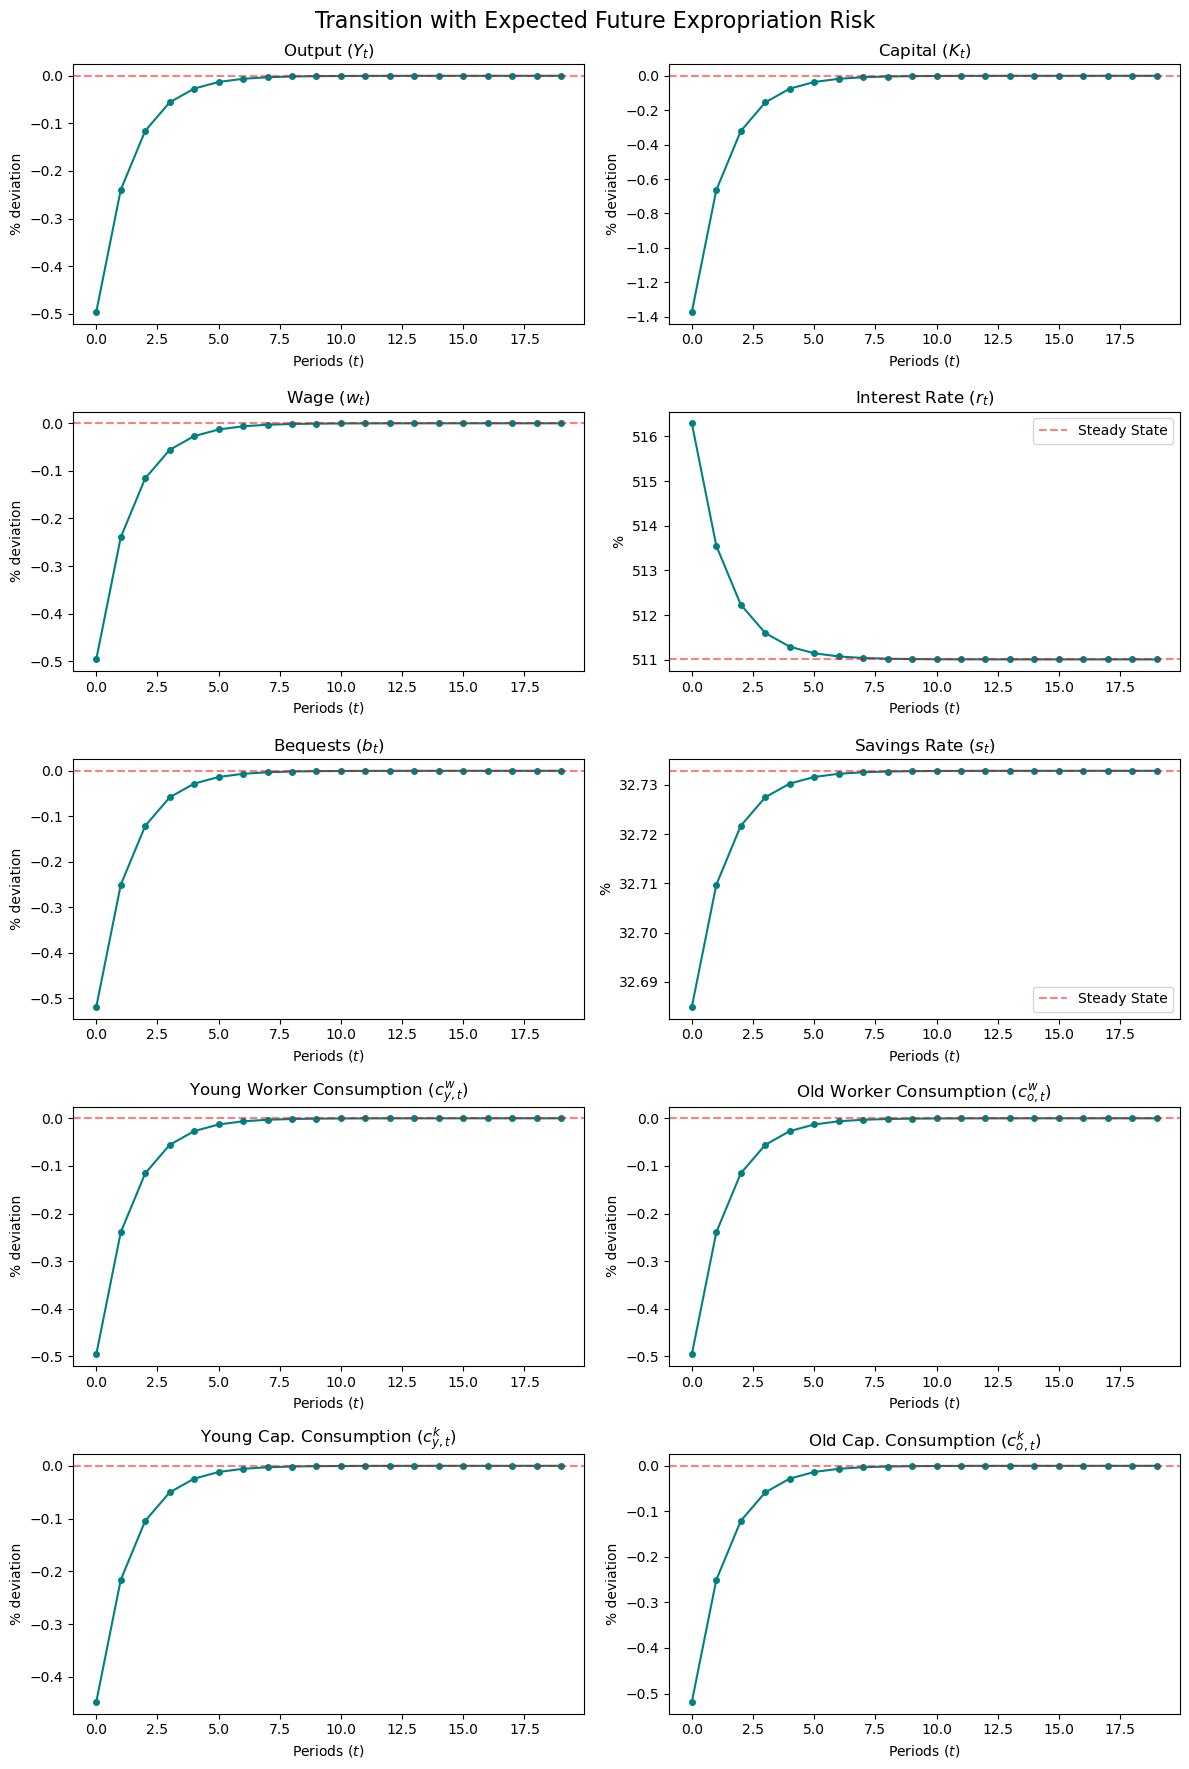

In [11]:
# Simulate transition path where uncertainty hits in t=0, but tau remains 0.
sim_uncert = simulate_olg(ss_base.K, T=20, par=par, uncertain=True)

# Plot transition
plot_simulation(sim_uncert, "Transition with Expected Future Expropriation Risk")


This new steady state resides squarely in a middle ground compared to Parts 2 and 5. Capital accumulation and output fundamentally underperform the purely deterministic `tau_a=0.00` landscape because unceasing uncertainty depresses sustained private savings momentum. Correspondingly however, it performs drastically better than a purely implemented deterministic heavy wealth tax, since capital returns are physically salvaged over time yielding a less depressed labor wedge. Effectively, the sheer fear of taxation structurally scars output through expectations alone without achieving any tangible redistribution.
